In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("samsung_global_sales_dataset.csv")

print("Original shape:", df.shape)
print("Nulls before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])


df["sale_date"] = pd.to_datetime(df["sale_date"])


df["storage"] = df["storage"].fillna("Unknown")
df["previous_device_os"] = df["previous_device_os"].fillna("Unknown")
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())


df["month_num"] = df["sale_date"].dt.month
df["day_of_week"] = df["sale_date"].dt.day_name()
df["revenue_category"] = pd.cut(
    df["revenue_usd"],
    bins=[0, 500, 2000, 10000, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)
df["discount_band"] = pd.cut(
    df["discount_pct"],
    bins=[-1, 0, 10, 20, 100],
    labels=["No Discount", "Low", "Medium", "High"]
)
df["is_returned"] = (df["return_status"] == "Returned").astype(int)

df.to_csv("samsung_cleaned.csv", index=False)
print("\nCleaned shape:", df.shape)
print("Nulls after cleaning:", df.isnull().sum().sum())
print("samsung_cleaned.csv saved!")

Original shape: (15500, 28)
Nulls before cleaning:
 storage               7849
previous_device_os    9373
customer_rating       4251
dtype: int64

Cleaned shape: (15500, 33)
Nulls after cleaning: 0
samsung_cleaned.csv saved!


eda_charts.png saved!


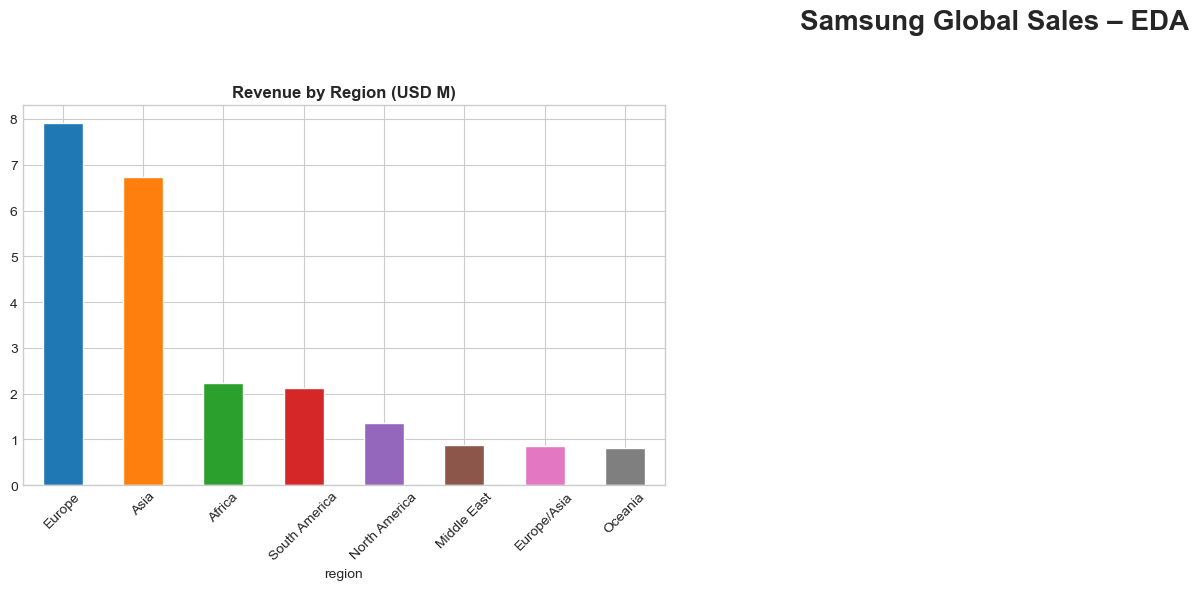

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("samsung_cleaned.csv")
plt.style.use("seaborn-v0_8-whitegrid")
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
          "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf","#aec7e8"]

fig = plt.figure(figsize=(20, 20))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)

ax1 = fig.add_subplot(4, 3, 1)
(df.groupby("region")["revenue_usd"].sum().sort_values(ascending=False)/1e6).plot(
    kind="bar", ax=ax1, color=colors, edgecolor="white")
ax1.set_title("Revenue by Region (USD M)", fontweight="bold")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()


eda_charts.png saved!


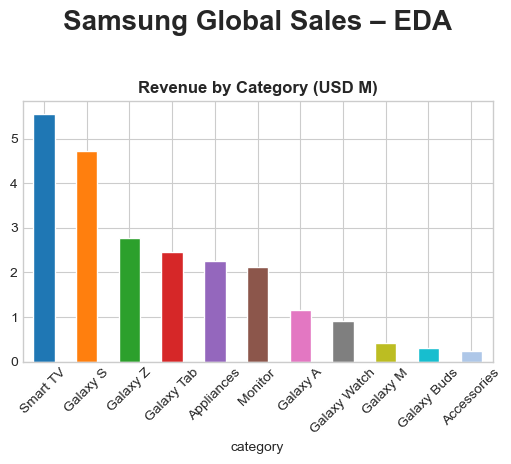

In [17]:
fig = plt.figure(figsize=(15, 15))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)

ax2 = fig.add_subplot(4, 3, 2)
(df.groupby("category")["revenue_usd"].sum().sort_values(ascending=False)/1e6).plot(
    kind="bar", ax=ax2, color=colors, edgecolor="white")
ax2.set_title("Revenue by Category (USD M)", fontweight="bold")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


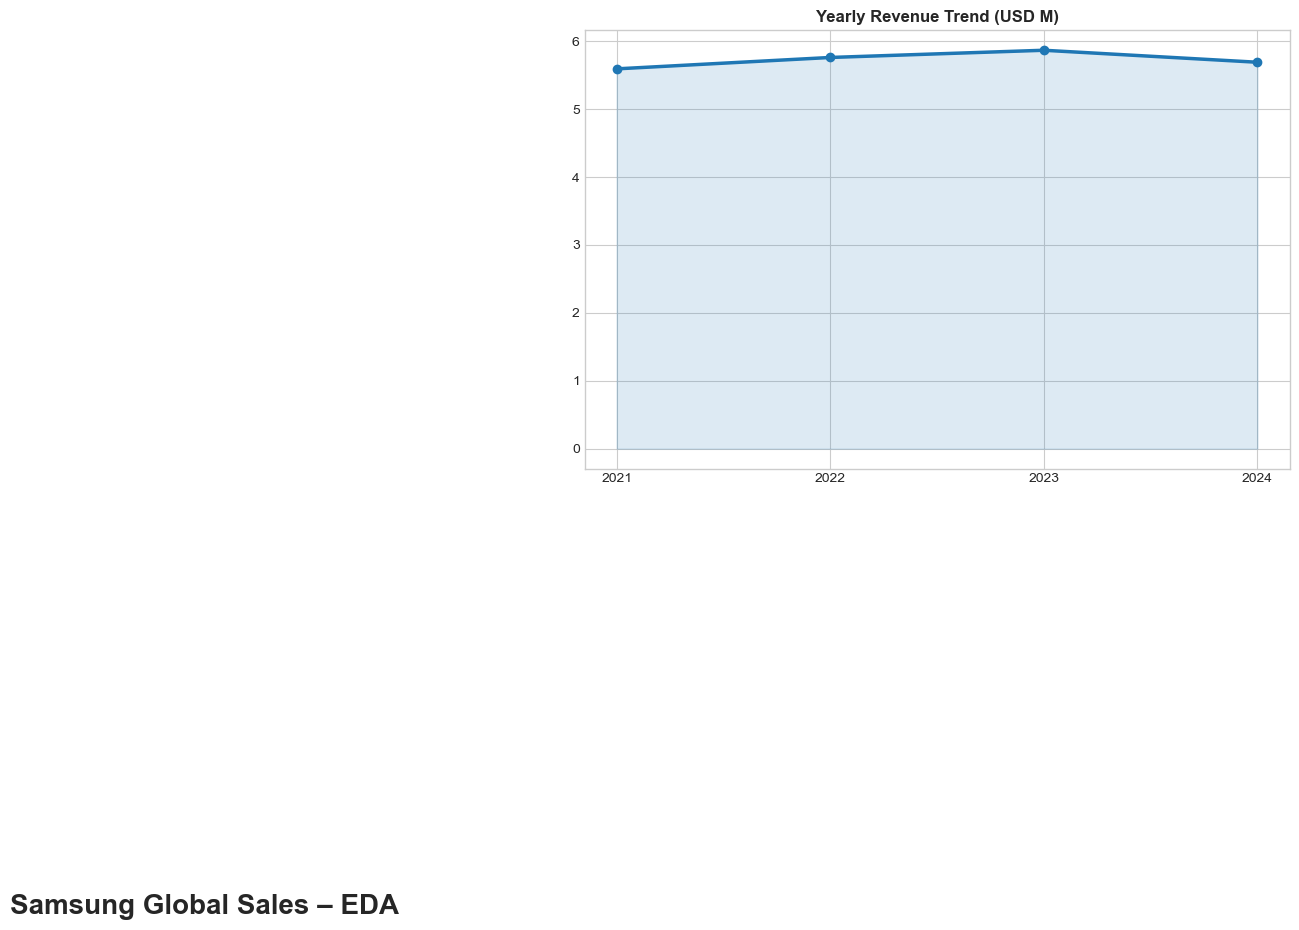

In [18]:
fig = plt.figure(figsize=(22, 20))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.50)
ax3 = fig.add_subplot(4, 3, 3)
yearly = df.groupby("year")["revenue_usd"].sum()/1e6
ax3.plot(yearly.index, yearly.values, marker="o", linewidth=2.5, color="#1f77b4")
ax3.fill_between(yearly.index, yearly.values, alpha=0.15, color="#1f77b4")
ax3.set_title("Yearly Revenue Trend (USD M)", fontweight="bold")
ax3.set_xticks(yearly.index)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


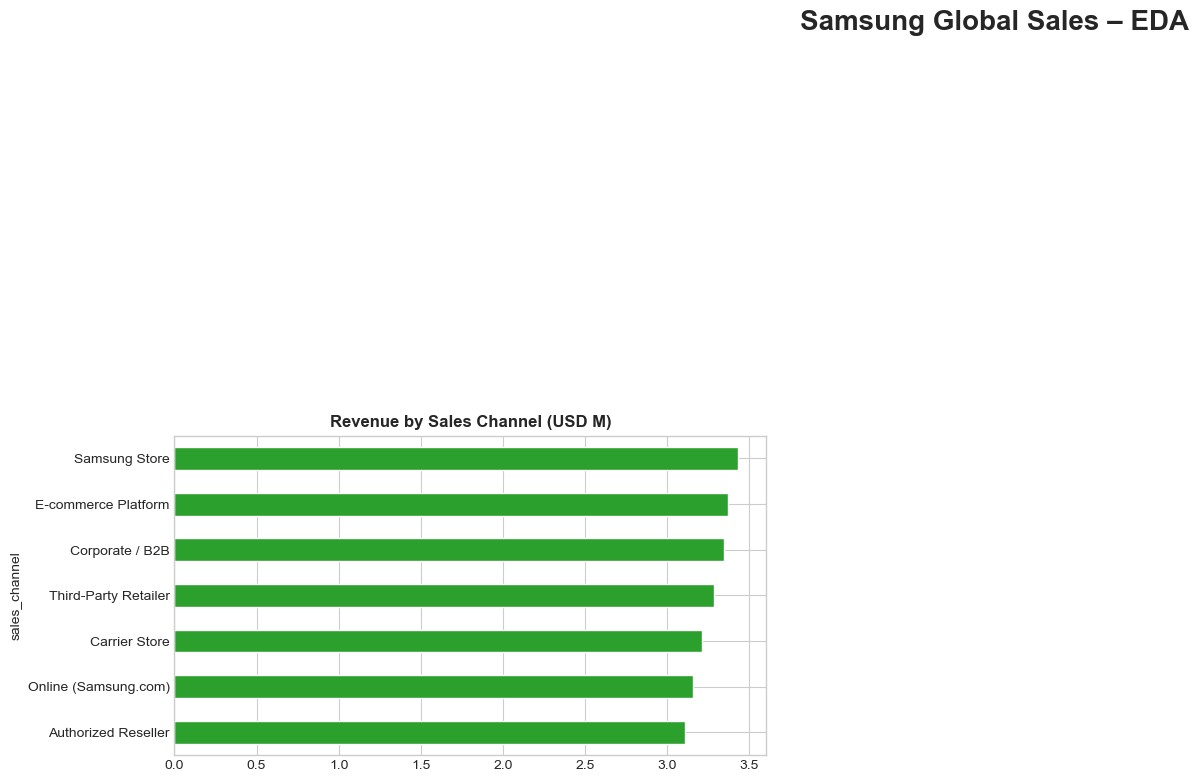

In [19]:
fig = plt.figure(figsize=(20, 15))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax4 = fig.add_subplot(4, 3, 4)
(df.groupby("sales_channel")["revenue_usd"].sum().sort_values()/1e6).plot(
    kind="barh", ax=ax4, color="#2ca02c", edgecolor="white")
ax4.set_title("Revenue by Sales Channel (USD M)", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


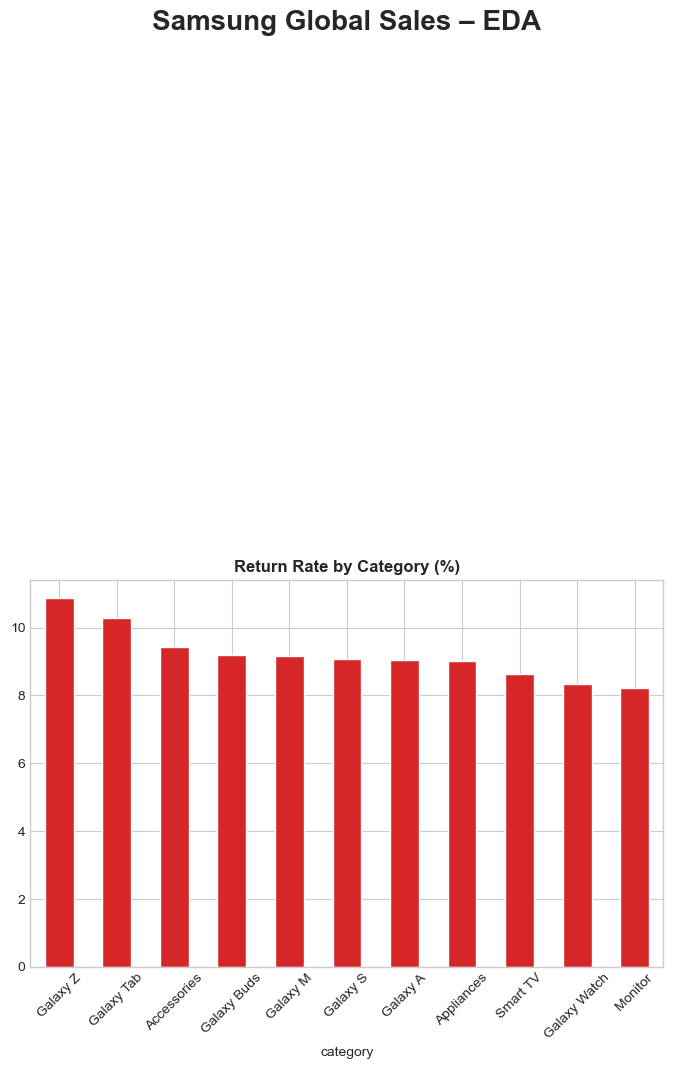

In [20]:
fig = plt.figure(figsize=(20, 20))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax5 = fig.add_subplot(4, 3, 5)
(df.groupby("category")["is_returned"].mean()*100).sort_values(ascending=False).plot(
    kind="bar", ax=ax5, color="#d62728", edgecolor="white")
ax5.set_title("Return Rate by Category (%)", fontweight="bold")
ax5.tick_params(axis="x", rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


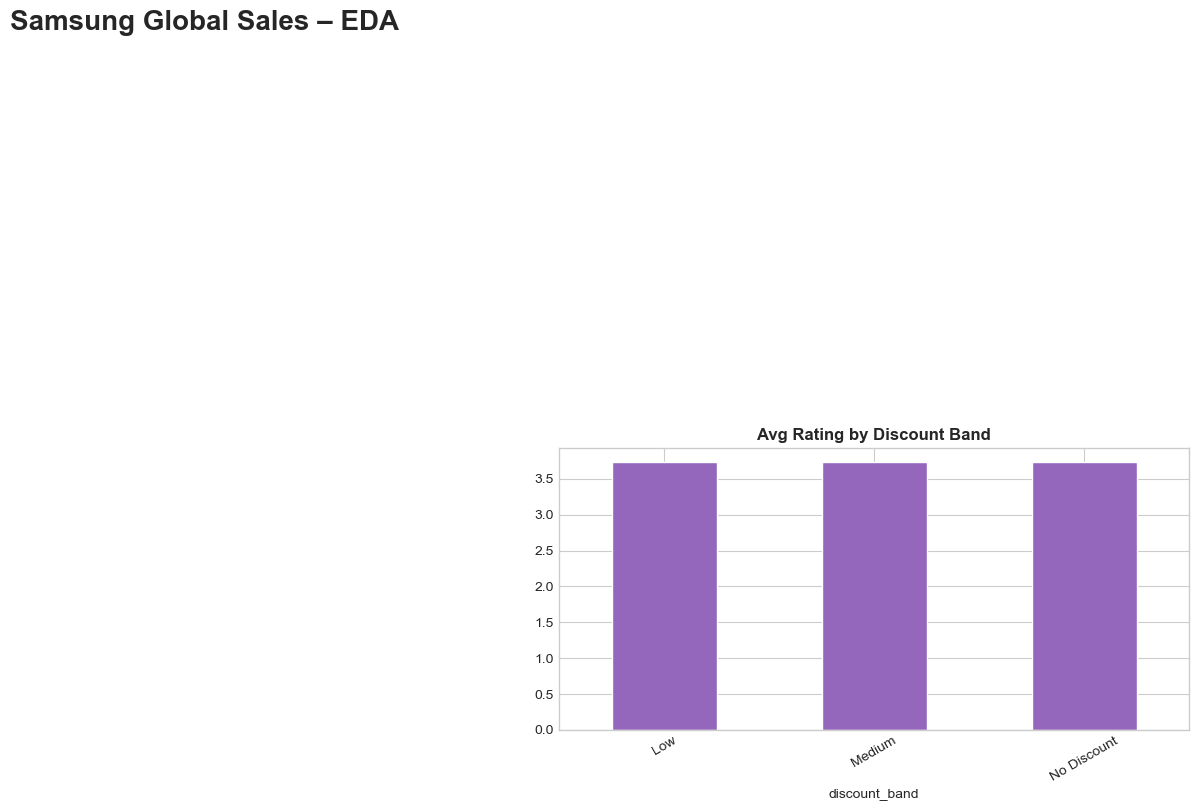

In [21]:
fig = plt.figure(figsize=(20, 15))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax6 = fig.add_subplot(4, 3, 6)
df.groupby("discount_band")["customer_rating"].mean().plot(
    kind="bar", ax=ax6, color="#9467bd", edgecolor="white")
ax6.set_title("Avg Rating by Discount Band", fontweight="bold")
ax6.tick_params(axis="x", rotation=30)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


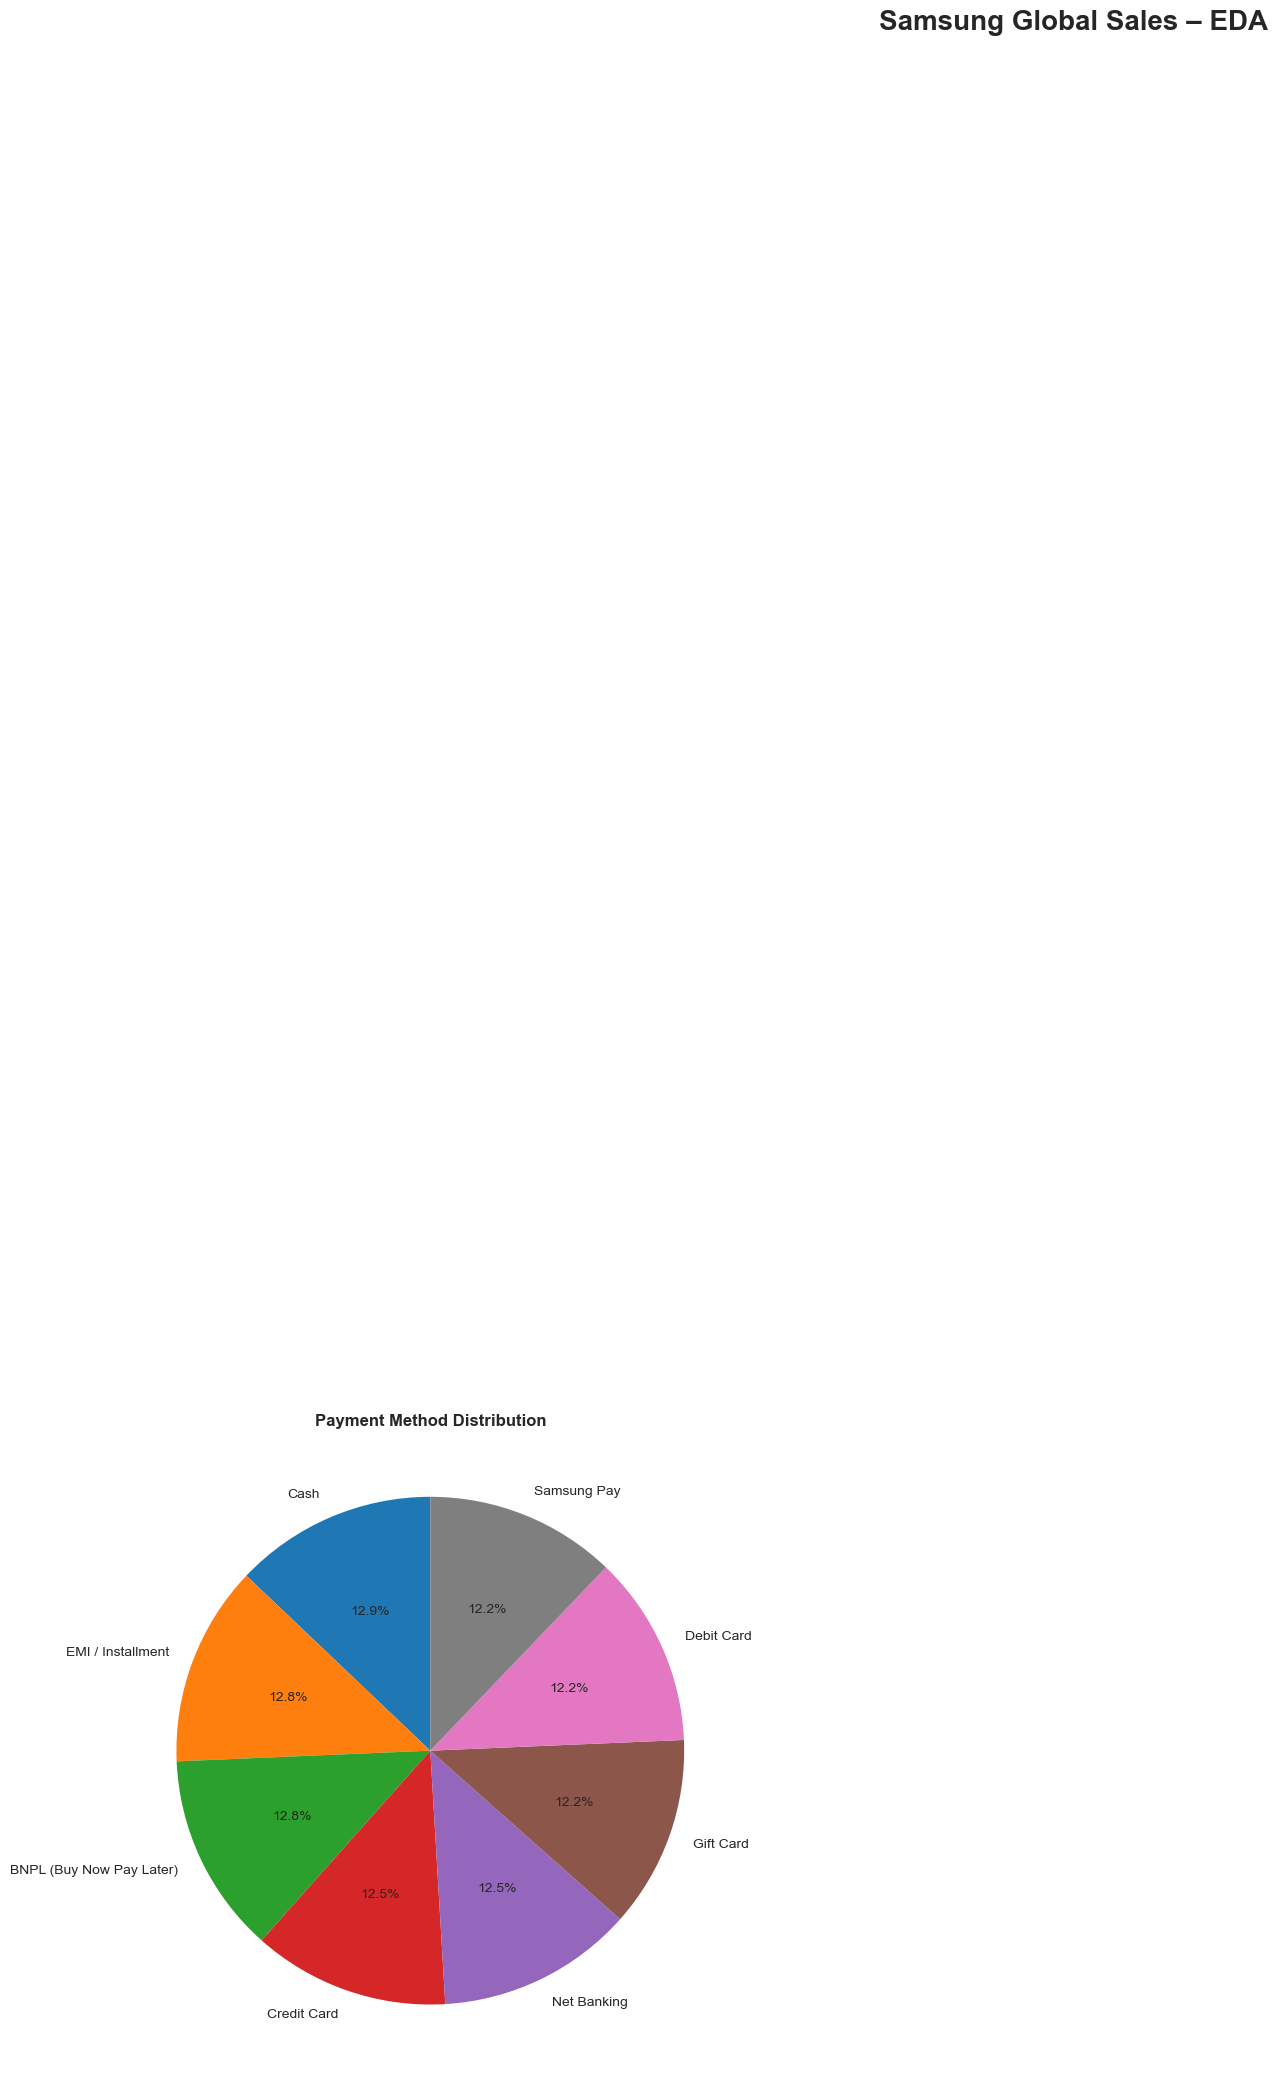

In [22]:
fig = plt.figure(figsize=(22, 28))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax7 = fig.add_subplot(4, 3, 7)
pay = df["payment_method"].value_counts()
ax7.pie(pay.values, labels=pay.index, autopct="%1.1f%%", colors=colors, startangle=90)
ax7.set_title("Payment Method Distribution", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


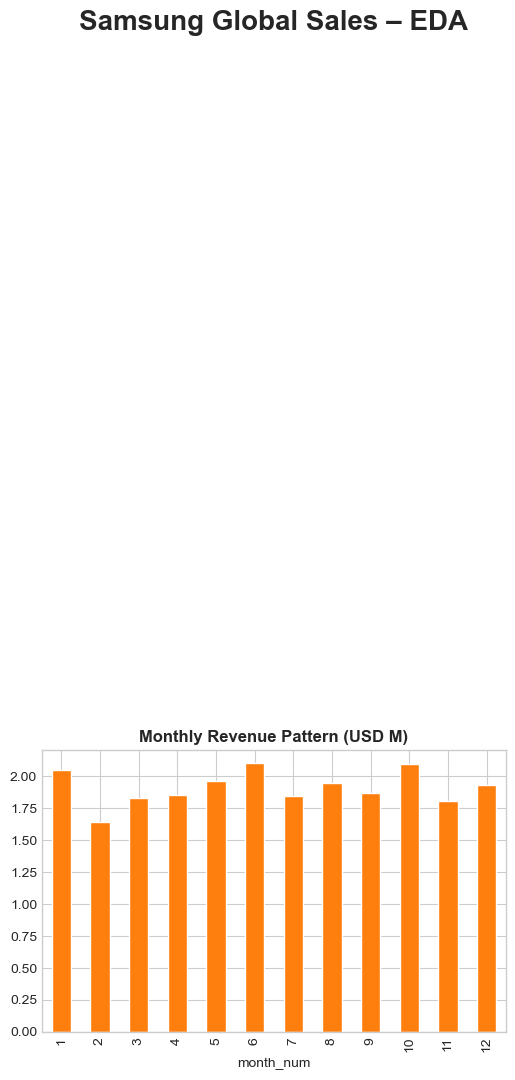

In [23]:
fig = plt.figure(figsize=(15, 14))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax8 = fig.add_subplot(4, 3, 8)
(df.groupby("month_num")["revenue_usd"].sum()/1e6).plot(
    kind="bar", ax=ax8, color="#ff7f0e", edgecolor="white")
ax8.set_title("Monthly Revenue Pattern (USD M)", fontweight="bold")
ax8.set_xticks(range(12)); ax8.set_xticklabels(range(1,13))
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


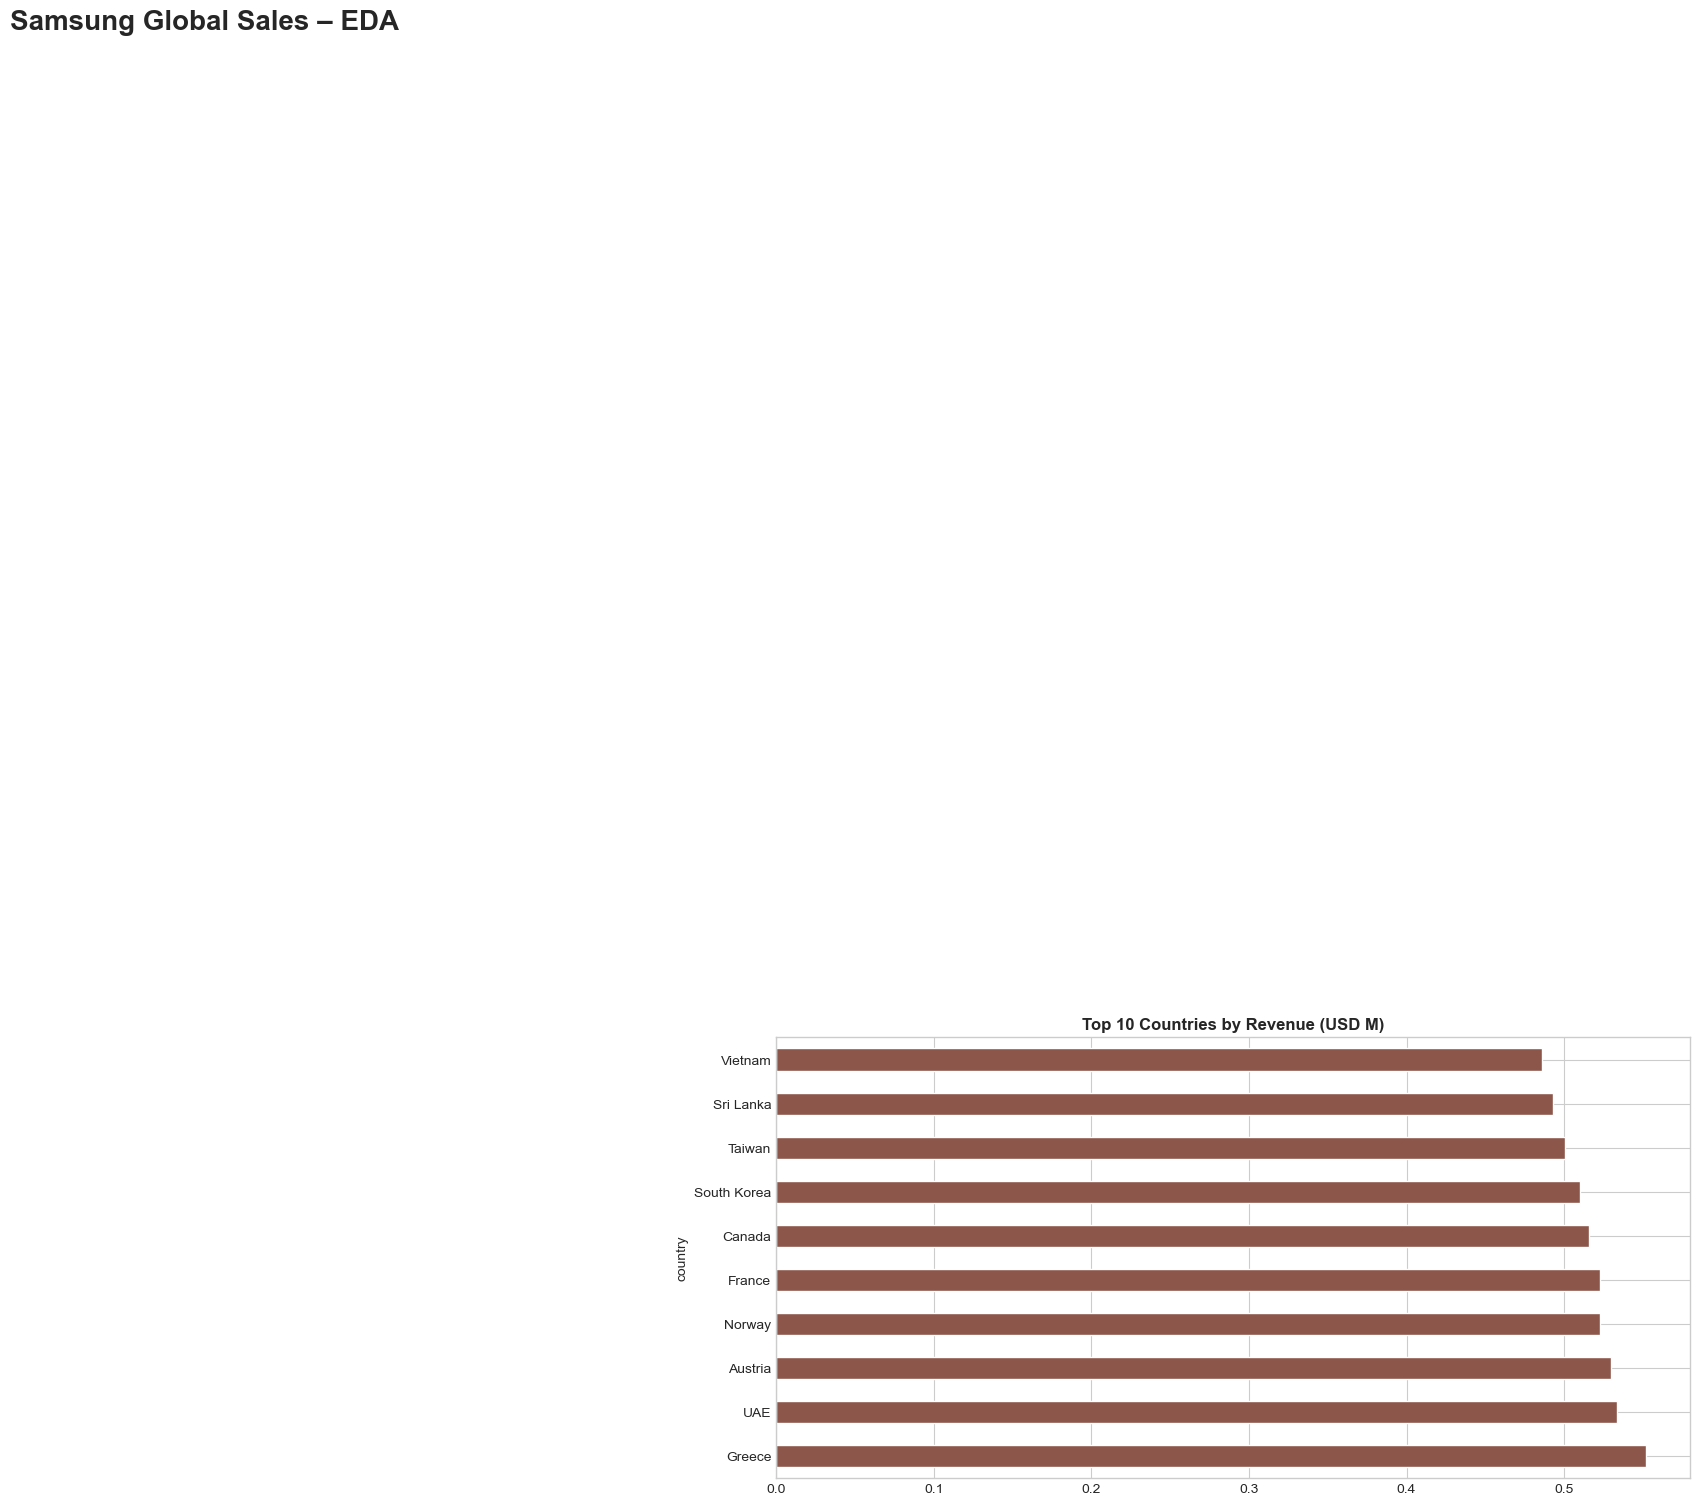

In [24]:
fig = plt.figure(figsize=(30, 20))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax9 = fig.add_subplot(4, 3, 9)
(df.groupby("country")["revenue_usd"].sum().sort_values(ascending=False).head(10)/1e6).plot(
    kind="barh", ax=ax9, color="#8c564b", edgecolor="white")
ax9.set_title("Top 10 Countries by Revenue (USD M)", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


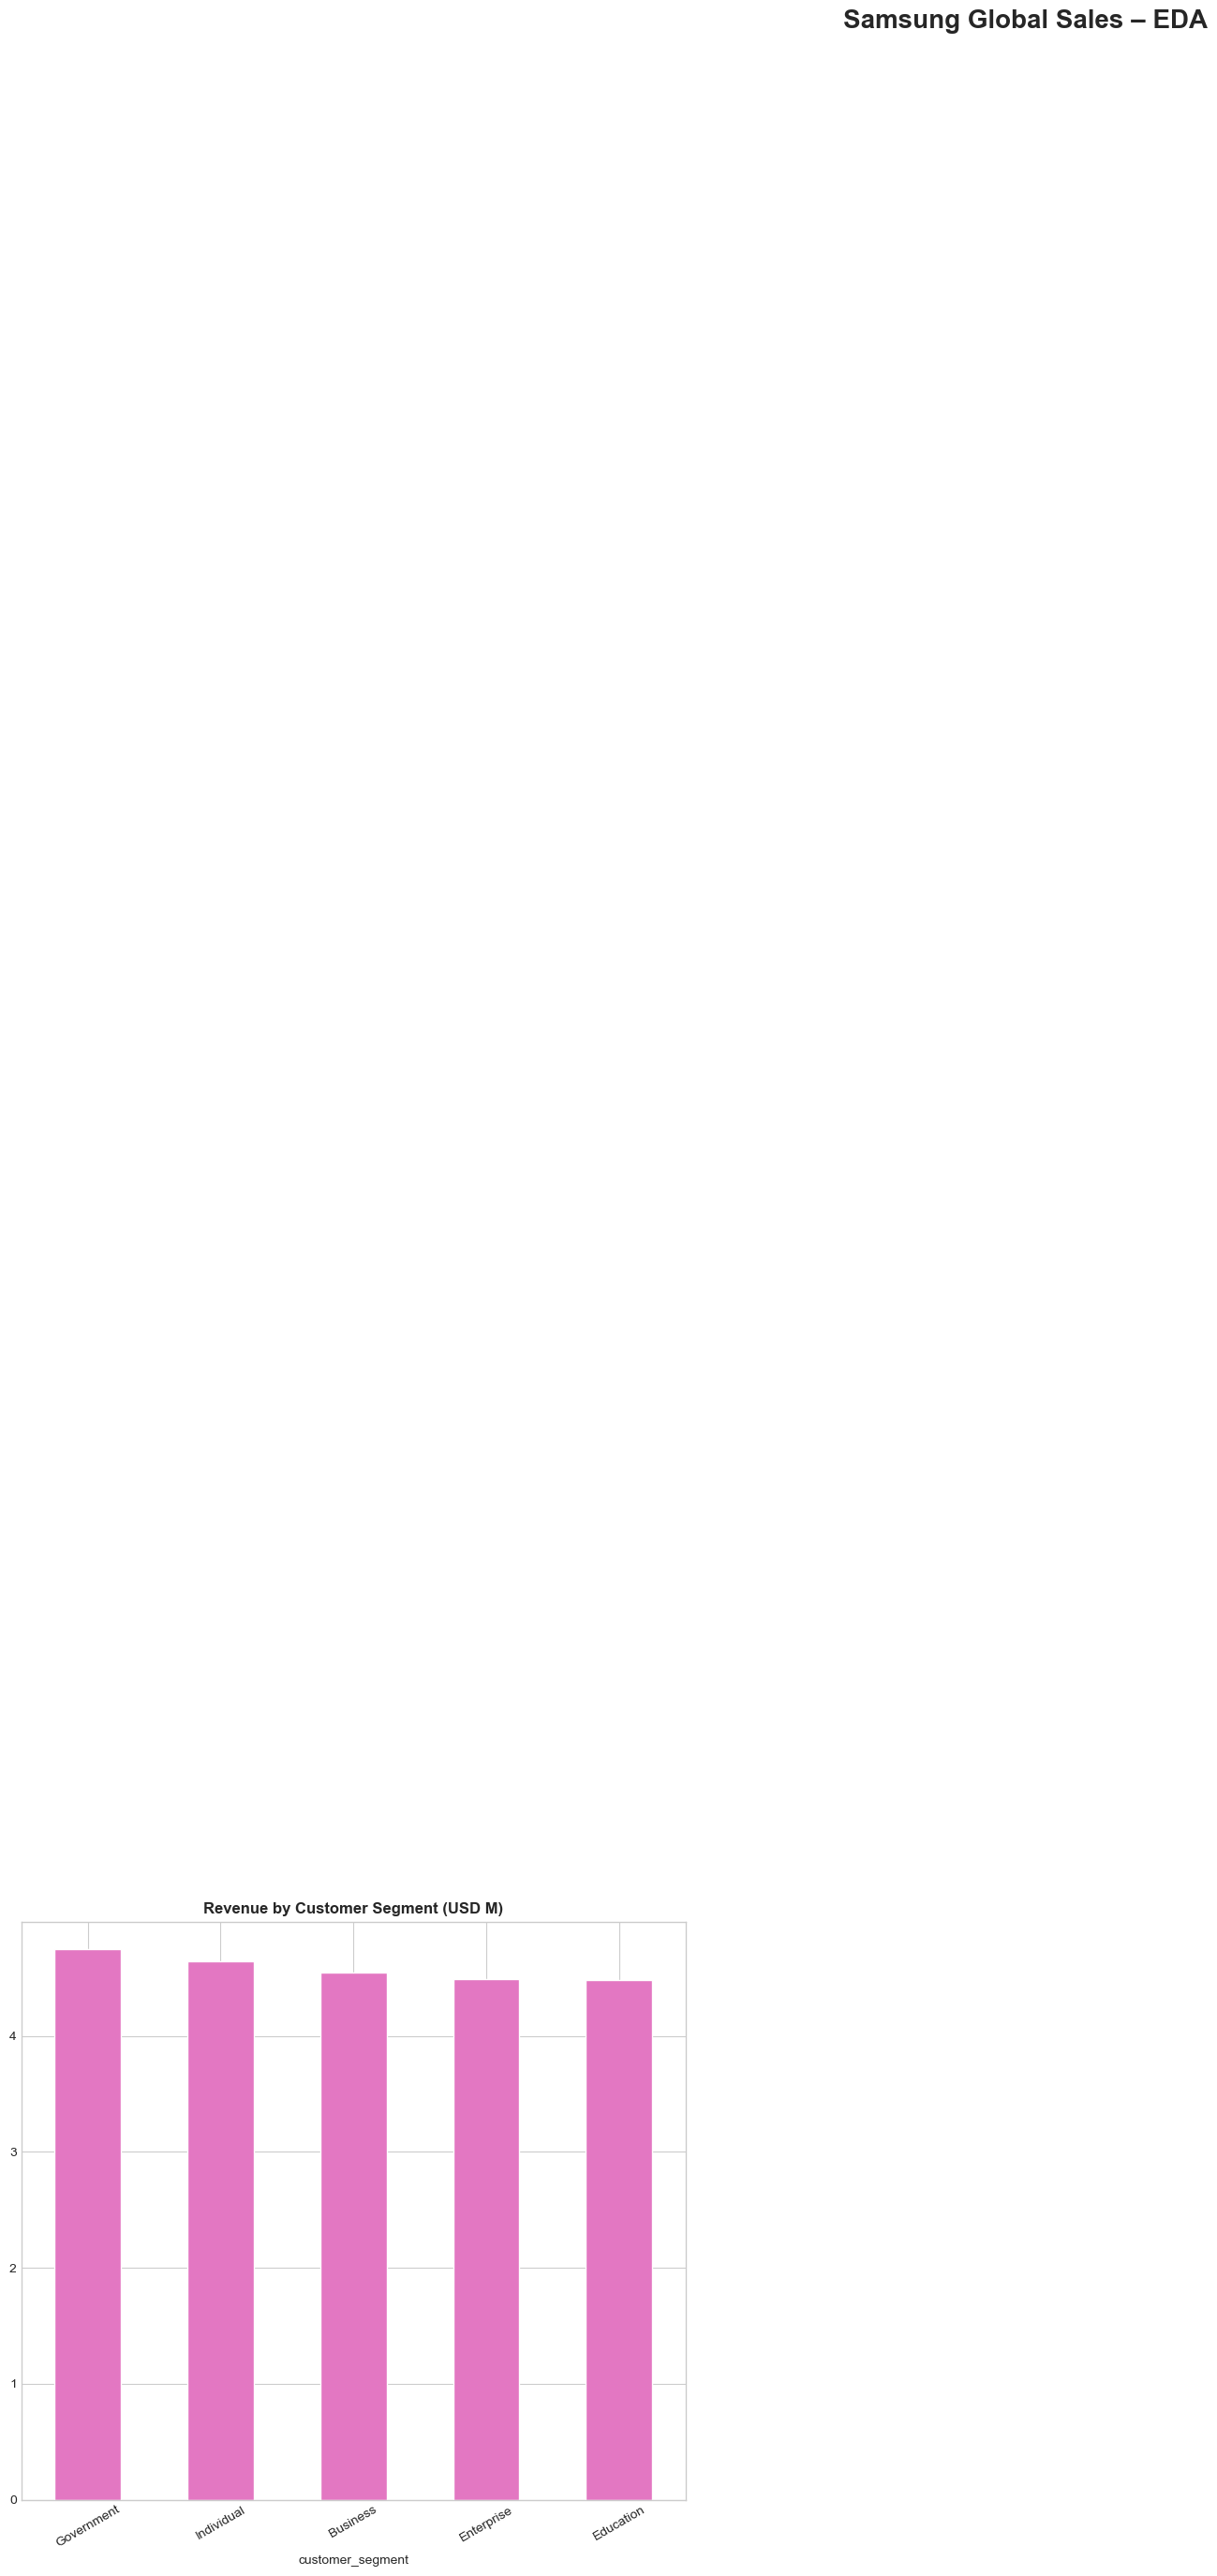

In [25]:
fig = plt.figure(figsize=(22, 28))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax10 = fig.add_subplot(4, 3, 10)
(df.groupby("customer_segment")["revenue_usd"].sum().sort_values(ascending=False)/1e6).plot(
    kind="bar", ax=ax10, color="#e377c2", edgecolor="white")
ax10.set_title("Revenue by Customer Segment (USD M)", fontweight="bold")
ax10.tick_params(axis="x", rotation=30)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


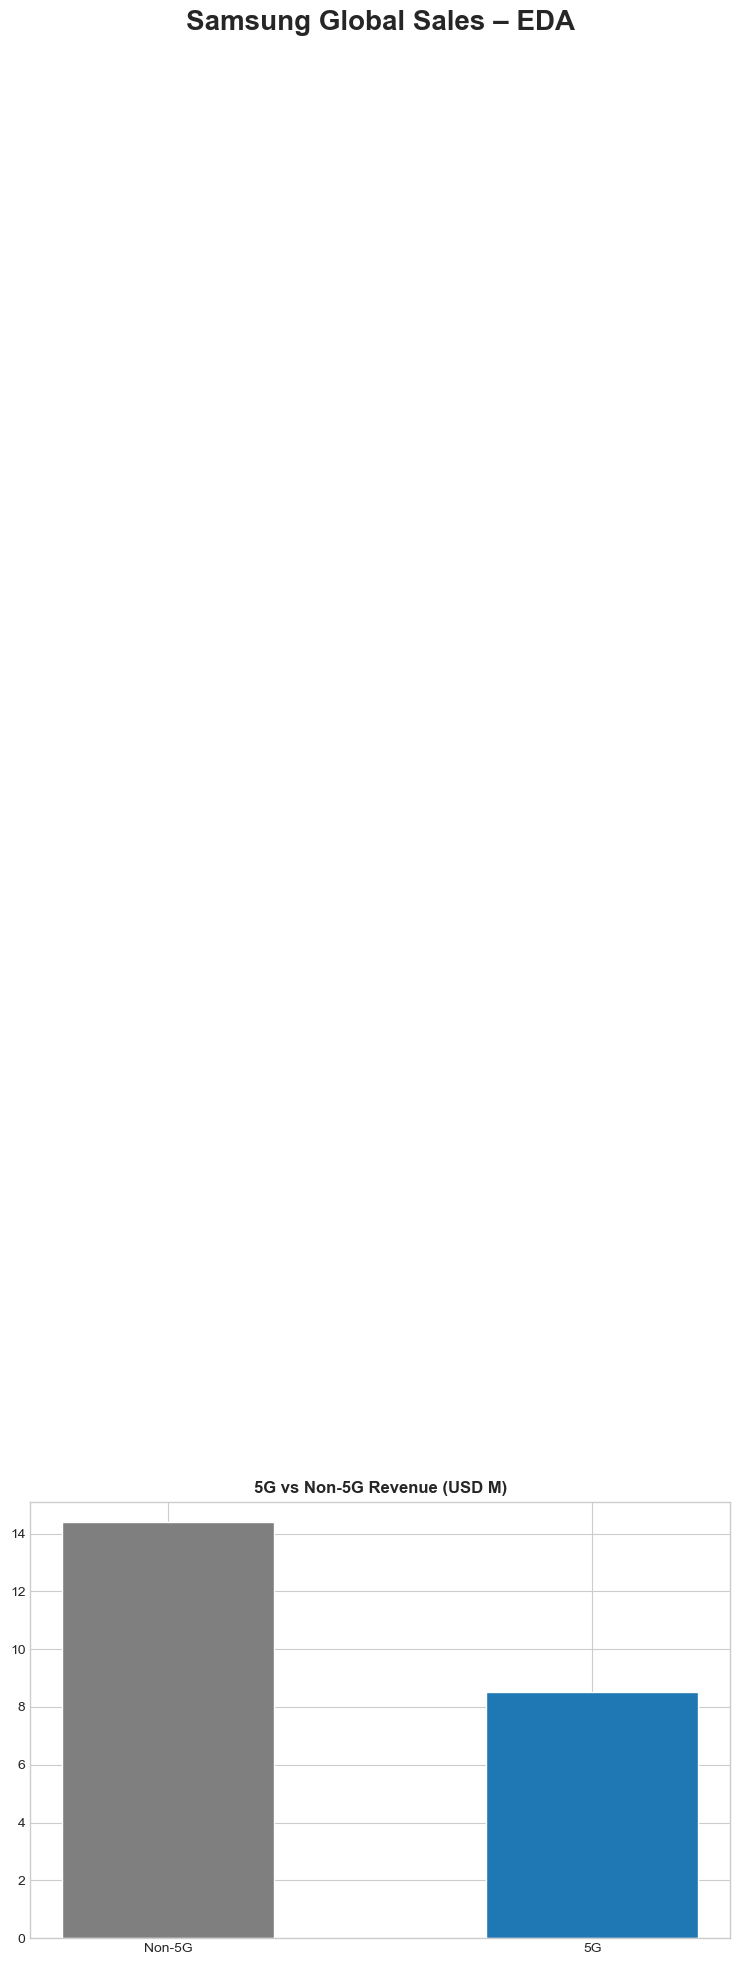

In [26]:
fig = plt.figure(figsize=(22, 20))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax11 = fig.add_subplot(4, 3, 11)
g5 = df.groupby("is_5g")["revenue_usd"].sum()/1e6
ax11.bar(["Non-5G","5G"], g5.values, color=["#7f7f7f","#1f77b4"], edgecolor="white", width=0.5)
ax11.set_title("5G vs Non-5G Revenue (USD M)", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

eda_charts.png saved!


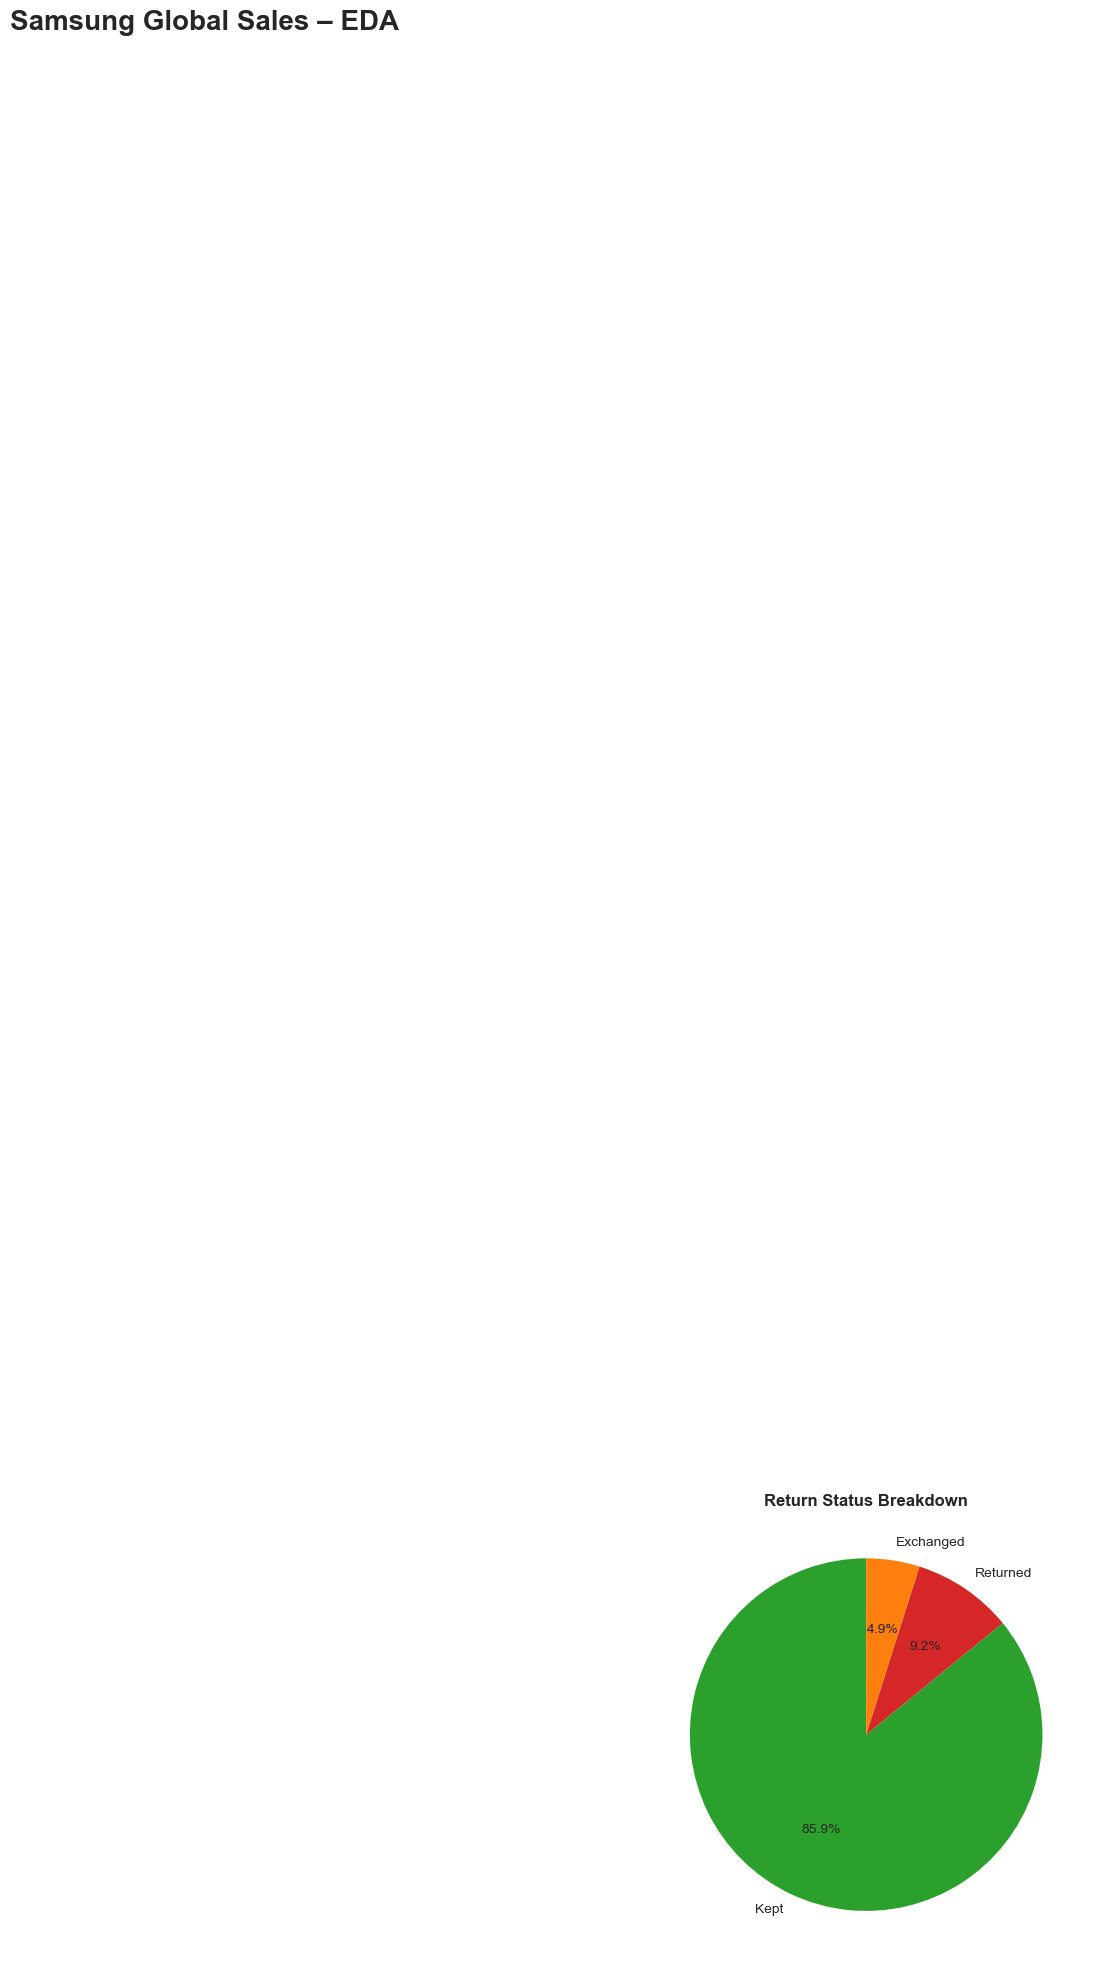

In [27]:
fig = plt.figure(figsize=(20, 20))
fig.suptitle("Samsung Global Sales – EDA", fontsize=20, fontweight="bold", y=0.98)
ax12 = fig.add_subplot(4, 3, 12)
ret = df["return_status"].value_counts()
ax12.pie(ret.values, labels=ret.index, autopct="%1.1f%%",
         colors=["#2ca02c","#d62728","#ff7f0e"], startangle=90)
ax12.set_title("Return Status Breakdown", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("eda_charts.png", dpi=150, bbox_inches="tight")
print("eda_charts.png saved!")
plt.show()

Decision Tree Accuracy : 0.5490
Random Forest Accuracy : 0.9984

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2840
           1       1.00      1.00      1.00      2790

    accuracy                           1.00      5630
   macro avg       1.00      1.00      1.00      5630
weighted avg       1.00      1.00      1.00      5630

ml_results.png saved!


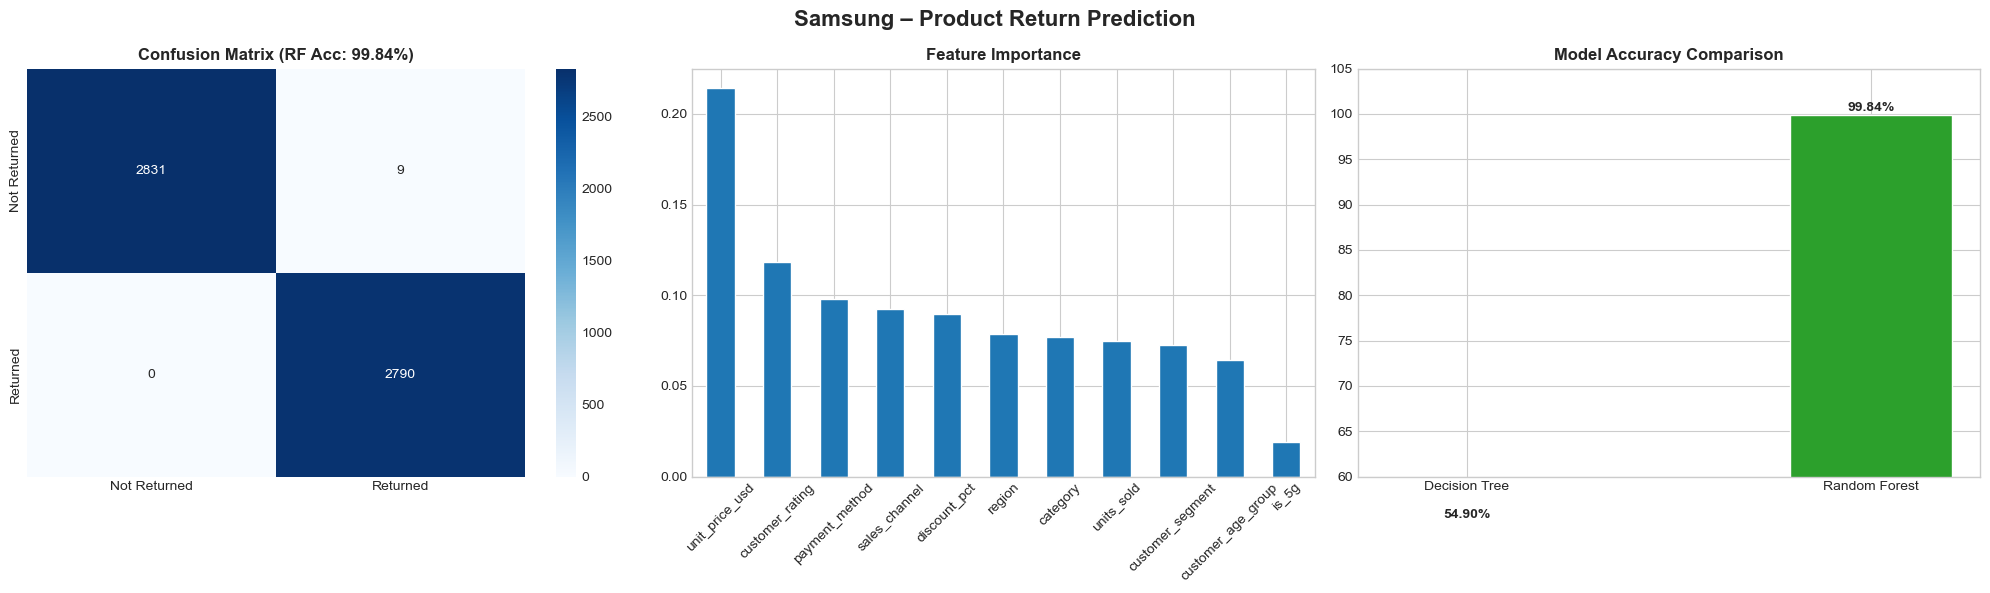

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("samsung_sales.csv")

features = ["category","sales_channel","customer_segment","customer_age_group",
            "payment_method","discount_pct","unit_price_usd","customer_rating",
            "units_sold","region","is_5g"]

df_ml = df[features + ["is_returned"]].copy()
le = LabelEncoder()
for col in ["category","sales_channel","customer_segment","customer_age_group",
            "payment_method","region","is_5g"]:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))


df_majority = df_ml[df_ml.is_returned==0]
df_minority  = df_ml[df_ml.is_returned==1]
df_minority_up = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_up])

X = df_balanced[features]
y = df_balanced["is_returned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Decision Tree Accuracy : {dt_acc:.4f}")
print(f"Random Forest Accuracy : {rf_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Samsung – Product Return Prediction", fontsize=16, fontweight="bold")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues",
            ax=axes[0], xticklabels=["Not Returned","Returned"],
            yticklabels=["Not Returned","Returned"])
axes[0].set_title(f"Confusion Matrix (RF Acc: {rf_acc:.2%})", fontweight="bold")

feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind="bar", ax=axes[1], color="#1f77b4", edgecolor="white")
axes[1].set_title("Feature Importance", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

models = ["Decision Tree", "Random Forest"]
accs = [dt_acc, rf_acc]
axes[2].bar(models, [a*100 for a in accs], color=["#ff7f0e","#2ca02c"], edgecolor="white", width=0.4)
axes[2].set_title("Model Accuracy Comparison", fontweight="bold")
axes[2].set_ylim(60, 105)
for i, (bar_x, acc) in enumerate(zip([0,1], accs)):
    axes[2].text(bar_x, acc*100+0.5, f"{acc:.2%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("ml_results.png", dpi=150, bbox_inches="tight")
print("ml_results.png saved!")
plt.show()

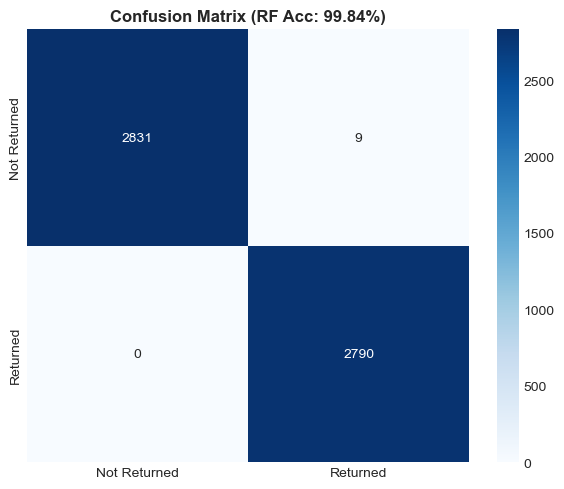

In [30]:
fig1 = plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Returned","Returned"],
            yticklabels=["Not Returned","Returned"])

plt.title(f"Confusion Matrix (RF Acc: {rf_acc:.2%})", fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

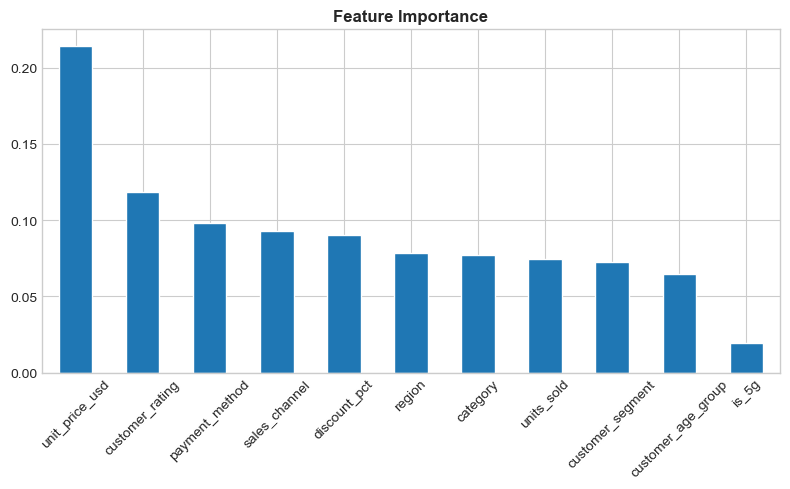

In [31]:
fig2 = plt.figure(figsize=(8,5))

feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind="bar", color="#1f77b4", edgecolor="white")

plt.title("Feature Importance", fontweight="bold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

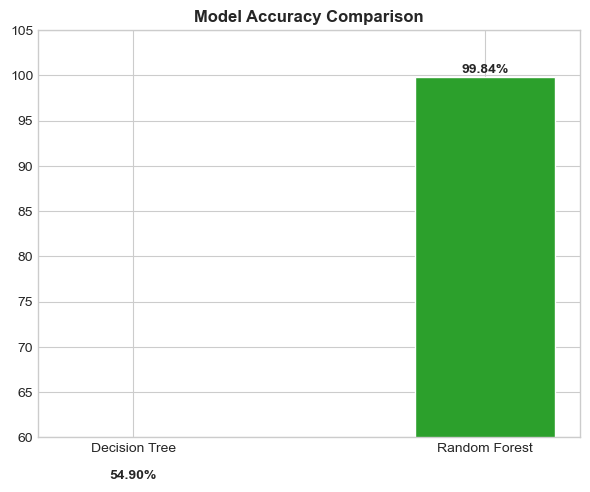

In [32]:
fig3 = plt.figure(figsize=(6,5))

models = ["Decision Tree", "Random Forest"]
accs = [dt_acc, rf_acc]

plt.bar(models, [a*100 for a in accs],
        color=["#ff7f0e","#2ca02c"], edgecolor="white", width=0.4)

plt.title("Model Accuracy Comparison", fontweight="bold")
plt.ylim(60, 105)

for i, acc in enumerate(accs):
    plt.text(i, acc*100+0.5, f"{acc:.2%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("model_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()